<a href="https://colab.research.google.com/github/futtaimao/FDS/blob/main/Notebooks/Fatima_Almarashda_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [1]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00


In [2]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [3]:
# Load dataset
from google.colab import files
uploaded = files.upload()


Saving Iris.csv to Iris.csv


In [4]:
irisData = Table.read_table("Iris.csv")
irisData.show(10)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa
6,5.4,3.9,1.7,0.4,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
8,5,3.4,1.5,0.2,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [5]:
# Q1. How many rows and columns does the dataset have? Print the column names.
numOfRows = irisData.num_rows
print('Number of Rows: ', numOfRows)
numOfColumns = irisData.num_columns
print('Number of Coulumns: ',numOfColumns)
columnNames = irisData.labels
print('Column Names: ',columnNames)

Number of Rows:  150
Number of Coulumns:  6
Column Names:  ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [6]:
# Q2. How many flowers are there per species? Use the .group() method.
speciesPerGroup = irisData.group('Species')
speciesPerGroup.show()

Species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [7]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.

#Taking the column of petal length
PetalLength = irisData.column('PetalLengthCm')
#Taking the column of petal width
PetalWidth = irisData.column('PetalWidthCm')

#Printing the results of petal length mean, min, and max
print('---- Petal Length Results ----')
print('Mean of Petal Length: ', np.mean(PetalLength))
print('Min of Petal Length: ', np.min(PetalLength))
print('Max of Petal Length: ', np.max(PetalLength))

#Printing the results of petal width mean, min, and max
print('---- Petal Width Results ----')
print('Mean of Petal Width: ', np.mean(PetalWidth))
print('Min of Petal Width: ', np.min(PetalWidth))
print('Max of Petal Width: ', np.max(PetalWidth))


---- Petal Length Results ----
Mean of Petal Length:  3.75866666667
Min of Petal Length:  1.0
Max of Petal Length:  6.9
---- Petal Width Results ----
Mean of Petal Width:  1.19866666667
Min of Petal Width:  0.1
Max of Petal Width:  2.5


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

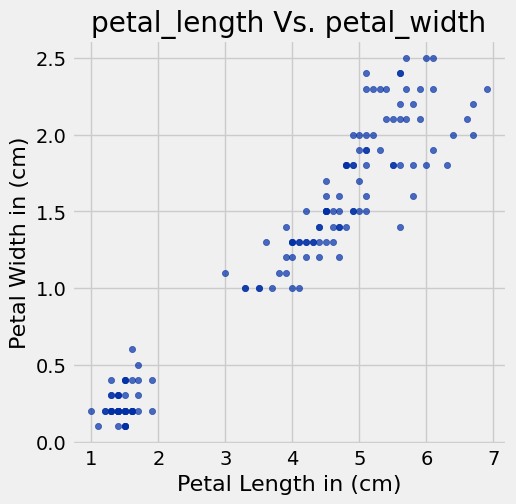

In [8]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.

#Using scatter function to create a scatter plot
irisData.scatter('PetalLengthCm', 'PetalWidthCm')
#Adding a title to the plot
plt.title('petal_length Vs. petal_width')
#Labeling the X-axis
plt.xlabel('Petal Length in (cm)')
#Labeling the Y-axis
plt.ylabel('Petal Width in (cm)')
plt.show()

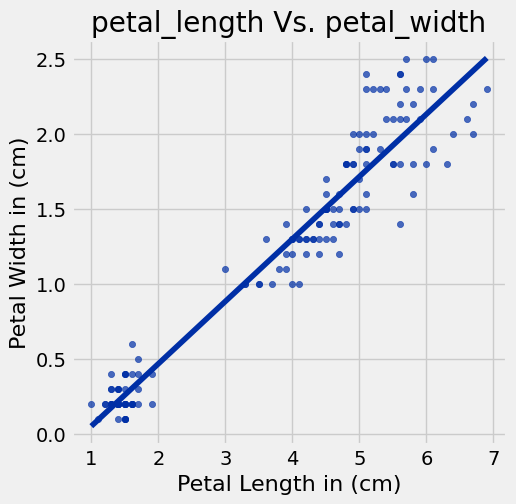

In [9]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.
irisData.scatter('PetalLengthCm', 'PetalWidthCm', fit_line = True)
plt.title('petal_length Vs. petal_width')
plt.xlabel('Petal Length in (cm)')
plt.ylabel('Petal Width in (cm)')
plt.show()

#Describing the pattern observed:
#We can observe a clear positive linear relationship between petal length and petal width
#Also, we can say that when petal length increases, petal width tends to increase

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [10]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [11]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [12]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [13]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [14]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length.
# Write the full regression equation.

#Using the helper function above to find the slop 'm'
m = slope(irisData, 'PetalLengthCm', 'PetalWidthCm')
#Using the helper function above to find the intercept 'b'
b = intercept(irisData, 'PetalLengthCm', 'PetalWidthCm')

print('Slope: ', m)
print('Intercept: ', b)

#Printing the full regression equation
print('Full Regression Equation: y=', m ,'* x +(', b,')')

Slope:  0.416419132285
Intercept:  -0.366514045217
Full Regression Equation: y= 0.416419132285 * x +( -0.366514045217 )


In [15]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.
inputOfPetalLength = 4.5
predictedPetalWidth = m * inputOfPetalLength + b
print('Computing...')
print('Full Regression Equation: y=', m ,'* x', b)
print('y= m *' ,inputOfPetalLength, '+ b')
print('Pridected Petal Width Using The Equation = ',predictedPetalWidth)

Computing...
Full Regression Equation: y= 0.416419132285 * x -0.366514045217
y= m * 4.5 + b
Pridected Petal Width Using The Equation =  1.50737205007


In [16]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak?
#Positive or negative? Explain in 2-3 sentences.
correraltion = correlation(irisData,'PetalLengthCm', 'PetalWidthCm')
print('Correlation Between Petal Length and Petal Width =', correraltion)

#Explanation of correlation result:
#The result of correlation coeffecient r between petal length and width indicates that
#there is a very strong linear relationship between the two variables.
#Since the value of r = 0.9627, and it is very close to +1, the variables move together almost perfectly.

Correlation Between Petal Length and Petal Width = 0.962757097051


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [17]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the
#residuals (actual - predicted) as new columns to the table. Display the first 8 rows.

#Computing predicted values using the helper function in task 3
predicted = m * irisData.column('PetalLengthCm') + b
#Computing residuals, actual - predicted
residuals = irisData.column('PetalWidthCm') - predicted
#Adding both arrays as new columns to the table irisData
iris_with_pred = irisData.with_columns(
    'Predicted Petal Width', predicted,
    'Residual',              residuals
)
#Showing first 10 rows
iris_with_pred.show(10)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predicted Petal Width,Residual
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147
9,4.4,2.9,1.4,0.2,Iris-setosa,0.216473,-0.0164727
10,4.9,3.1,1.5,0.1,Iris-setosa,0.258115,-0.158115


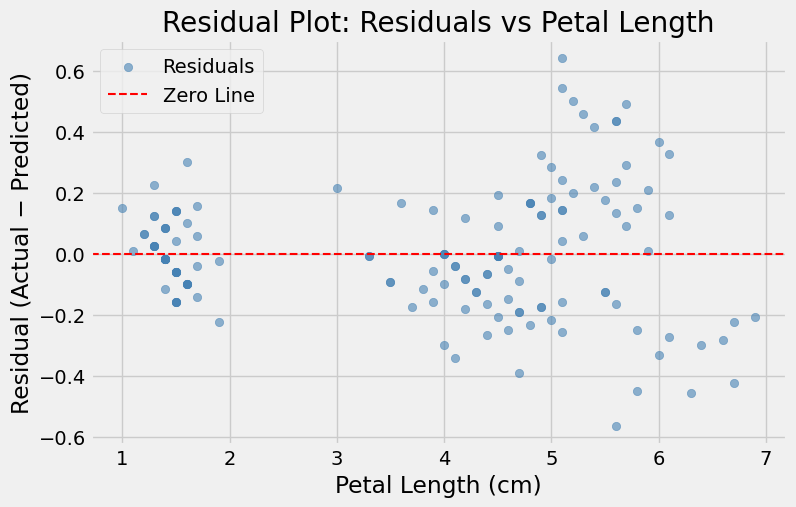

In [18]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences,
# interpret what this plot tells you about how well the linear model fits the data.

#Extracting arrays for plotting
petal_len_arr = iris_with_pred.column('PetalLengthCm')
residual_arr  = iris_with_pred.column('Residual')

#Plottting residuals vs petal_length
plt.figure(figsize=(8, 5))
plt.scatter(petal_len_arr, residual_arr, color='steelblue', alpha=0.6, label='Residuals')

#Drawing a horizontal red dashed reference line at y = 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Line')

plt.title('Residual Plot: Residuals vs Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Residual (Actual − Predicted)')
plt.legend()
plt.show()

#Interpretation:
#The residuals are scattered both above and below the zero line across the entire
#range of petal lengths, which suggests the linear model is generally appropriate.
#Overall, the linear model is a reasonably good fit given the high r ≈ 0.96,
#but the pattern suggests the relationship may differ slightly across species,
#indicating the relationship may be non-linear across groups which the linear
#model cannot fully capture.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.